<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Samudra(CNN)/DLAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries:

In [2]:
!pip install kaggle tensorflow scikit-learn

Mount Drive & Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

fake_df = pd.read_csv('/content/drive/MyDrive/Fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/True.csv')

# Add labels: 0 = fake, 1 = real
fake_df['label'] = 0
true_df['label'] = 1

# Combine datasets
df = pd.concat([fake_df[['title','text','label']], true_df[['title','text','label']]], ignore_index=True)

# Combine title + text for better representation
df['text'] = df['title'] + ' ' + df['text']
df = df[['text','label']]

Mounted at /content/drive


Text Preprocessing

In [4]:
import re
def preprocess_text(text):
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove non-alphabet characters
    text = text.lower().strip()
    return text

df['text'] = df['text'].apply(preprocess_text)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)


Tokenization & Padding

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 150
max_len = 150

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=max_len)

Build Text CNN Model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    Conv1D(128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_len))
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 150, 128)       │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 146, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,889 (460.50 KB)

 Trainable params: 117,889 (460.50 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [19]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8755 - loss: 0.2637 - val_accuracy: 0.9739 - val_loss: 0.0709
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9760 - loss: 0.0671 - val_accuracy: 0.9778 - val_loss: 0.0602
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9861 - loss: 0.0397 - val_accuracy: 0.9800 - val_loss: 0.0623
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9925 - loss: 0.0227 - val_accuracy: 0.9756 - val_loss: 0.0726
Epoch 5/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9939 - loss: 0.0181 - val_accuracy: 0.9801 - val_loss: 0.0623
Epoch 6/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9972 - loss: 0.0091 - val_accuracy: 0.9840 - val_loss: 0.0630
Epoch 7/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9976 - loss: 0.0072 - val_accuracy: 0.9801 - val_loss: 0.0721
Epoch 8/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9963 - loss: 0.0098 - val_accuracy: 0

Evaluate Model

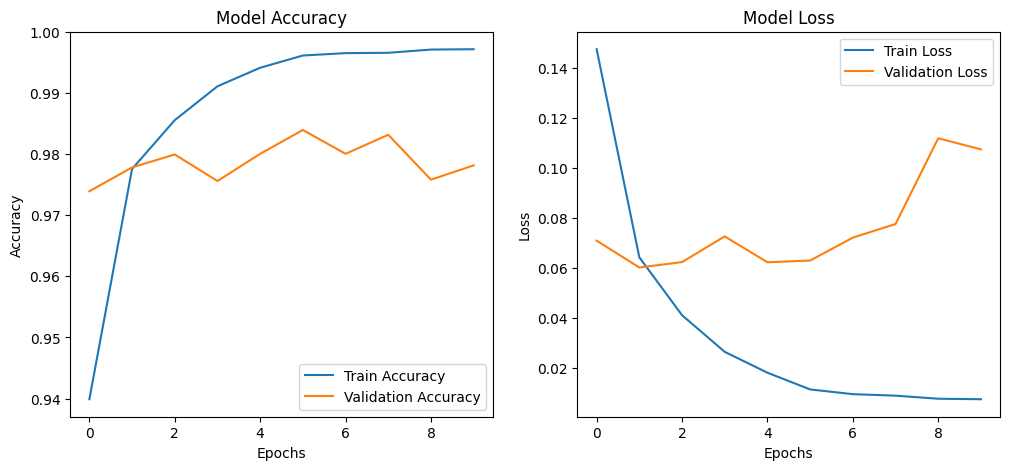


Test Accuracy: 97.82%
Test Loss: 0.1074
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Confusion Matrix:
 [[4687   46]
 [ 150 4097]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      4733
           1       0.99      0.96      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980


Performance – Text CNN Model

Metric     Training Set    Test Set       
----------------------------------------
Accuracy   0.9972          0.9782         
Loss       0.0075          0.1074         


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# --- Plot training & validation accuracy ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# --- Plot training & validation loss ---
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# --- Evaluate on test set ---
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# --- Predictions & metrics ---
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)

# Get final training accuracy and loss from history
train_accuracy = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]

# Print table
print("\nPerformance – Text CNN Model\n")
print(f"{'Metric':<10} {'Training Set':<15} {'Test Set':<15}")
print(f"{'-'*40}")
print(f"{'Accuracy':<10} {train_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Loss':<10} {train_loss:<15.4f} {test_loss:<15.4f}")



Confusion Matrix

281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


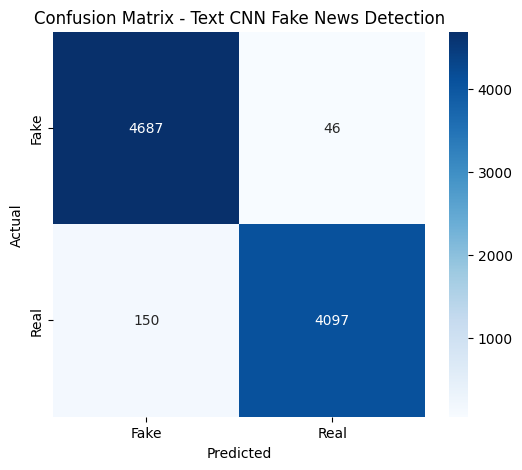

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict on test set
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Text CNN Fake News Detection')
plt.show()

Full Detection

In [21]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("📰 Fake News Detector")
print("Type 'exit' to quit.\n")

while True:
    news_text = input("Enter news article: ")

    if news_text.lower() == "exit":
        print("Exiting the detector. Goodbye! 👋")
        break

    new_text = [news_text]

    new_seq = tokenizer.texts_to_sequences(new_text)
    new_padded = pad_sequences(new_seq, maxlen=150)

    # Predict with trained CNN model
    prediction = model.predict(new_padded)

    # Show result
    if prediction[0][0] > 0.5:
        print("✅ This news is classified as REAL 📰")
    else:
        print("❌ This news is classified as FAKE 🚨")

    print("🔎 Confidence score:", float(prediction[0][0]))
    print("\n----------------------------\n")



📰 Fake News Detector
Type 'exit' to quit.



KeyboardInterrupt: Interrupted by user